In [2]:
import pandas as pd
import numpy as np
import re
import os
import ast
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import rdkit.Chem as Chem
from rdkit.Chem import AllChem, DataStructs

In [3]:
def extract_title_from_id(s):
    try:
        val = s.strip("{}").replace("'", "").strip()
        pdb_id = val.split('_')[1]
        return pdb_id if pdb_id else None
    except Exception:
        return None

def fill_minor_change_fields(minor_change, minor_change_ori, fields=("PDB RESOLUTION", "PDB EXPDTA")):
    for field in fields:
        # Build info dict (title: field_value)
        info_df = minor_change_ori[minor_change_ori[field].notna()]
        info_dict = {}
        for i, title in enumerate(info_df['Title']):
            title_key = str(title).upper() if isinstance(title, str) else title
            value = info_df[field].iloc[i]
            if title_key not in info_dict:
                info_dict[title_key] = value
            else:
                if not pd.isna(info_dict[title_key]) and info_dict[title_key] != value:
                    info_dict[title_key] = np.nan
        for idx, row in minor_change.iterrows():
            id_entry = row['ID']
            key = extract_title_from_id(str(id_entry))
            if key and key.upper() in info_dict:
                minor_change.at[idx, field] = info_dict[key.upper()]

def get_fingerprint(mol):
    mg = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
    return mg.GetFingerprint(mol)

def extract_kd_ki_ic50_obj(val):
    if isinstance(val, str) and '=' in val:
        return val.split('=')[0].strip()
    return None

# PDBbind data

In [4]:
PDBbind_path = '../../PDBbind24/index/INDEX_general_PL.2024'
pdbbind_columns = [
    'PDB code',    
    'resolution',     
    'release year',    
    'Kd/Ki',           
    'ligand name',     
    'reference'        
]
with open(PDBbind_path, 'r') as f:
    lines = f.readlines()[5:]  # skip header (5 lines)
records = []
for line in lines:
    if '//' in line:
        parts = line.split('//', 1)
        data_fields = parts[0].strip().split()
        comment_and_rest = parts[1].rstrip()
        closing_paren_idx = comment_and_rest.find(')') 
        if closing_paren_idx != -1:
            match = re.search(r'\((.*?)\)', comment_and_rest)
            comment = match.group(1) if match else ""
    
            reference = comment_and_rest[closing_paren_idx+1:].strip()
        else:
            comment = comment_and_rest
            reference = ""
        if len(data_fields) == 4:
            record = data_fields + [comment, reference]
            records.append(record)

PDBbind_df = pd.DataFrame(records, columns=pdbbind_columns)
print(len(PDBbind_df))
PDBbind_df.head(5)

27385


,PDB code,resolution,release year,Kd/Ki,ligand name,reference
0,2tpi,2.10,1982,Kd=49uM,2-mer,
1,4dfr,1.70,1982,Kd=960pM,MTX,Kd value depends on PH change: Kd=0.023nM at p...
2,5tln,2.30,1982,Ki=0.43uM,BAN,incomplete ligand structure
3,4tln,2.30,1982,Ki=190uM,LNO,
4,3ptb,1.70,1983,Ki=31nM,BEN,ligand is benzamidine; Enzymatic assay


Check the groups in categories that have the enantiomers bioactivity data

In [5]:
def extract_pdbbind_info(pdbbind_info):
    if not pdbbind_info or not isinstance(pdbbind_info, dict):
        return None, None
    kd_ki = pdbbind_info.get('Kd/Ki')
    reference = pdbbind_info.get('reference')
    ligand_name = pdbbind_info.get('ligand name')
    kd_ki_value = str(kd_ki) if kd_ki is not None and pd.notna(kd_ki) else None
    reference_value = str(reference) if reference is not None and pd.notna(reference) and str(reference).strip() != "" else None
    return kd_ki_value, reference_value, ligand_name

In [6]:
manual_check_folder = '../Data/Manual_curation'
all_matched_records = []
category_mapping = {
    '1.2.1': '1.1',
    '1.2.2': '1.2',
    '1.2.3': '1.3',
    '1.1': '2',
}

for file in os.listdir(manual_check_folder):
    if file.endswith('.csv') and not 'manualcheck_invalid' in file:
        file_path = os.path.join(manual_check_folder, file)
        df = pd.read_csv(file_path, delimiter='\t')
        df_non4letter_title = df[df['Title'].astype(str).str.len() != 4]
        merge_pdbbind = PDBbind_df.copy()
        merge_pdbbind['PDB code'] = merge_pdbbind['PDB code'].astype(str).str.strip().str.lower()
        merge_pdbbind['ligand name'] = merge_pdbbind['ligand name'].astype(str).str.strip()
        pdbbind_dict = {
            (row['PDB code'], row['ligand name']): row
            for _, row in merge_pdbbind.iterrows()
        }
        grouped = df_non4letter_title.groupby('group')
        for group_name, group_df in grouped:
            for idx, row in group_df.iterrows():
                ids = row['ID']
                # Remap category if needed
                category_original = row['category_manual_check']
                category_remapped = category_mapping.get(str(category_original), str(category_original))
                if pd.notna(ids):
                    if isinstance(ids, str) and ids.startswith('[') and ids.endswith(']'):
                        try:
                            ids_list = ast.literal_eval(ids)
                        except Exception:
                            ids_list = []
                    else:
                        ids_list = [ids]
                    for pdb_item in ids_list:
                        matched_record = {
                            'group': group_name,
                            'category': category_remapped,
                            'pdb_item': pdb_item,
                            'pdb_code': None,
                            'ligand_name': None,
                            'matched': False,
                            'pdbbind_info': None,
                        }
                        if isinstance(pdb_item, str) and '_' in pdb_item:
                            split_pdb = pdb_item.split('_')
                            if len(split_pdb) >= 3:
                                pdb_code = split_pdb[1].strip().lower()
                                ligand_name = split_pdb[2].strip()
                                m_layer = split_pdb[5].strip()
                                matched_record['pdb_code'] = pdb_code
                                matched_record['ligand_name'] = ligand_name
                                matched_record['m_layer'] = m_layer
                                pdbbind_info = pdbbind_dict.get((pdb_code, ligand_name))
                                if pdbbind_info is not None:
                                    matched_record['matched'] = True
                                    matched_record['pdbbind_info'] = pdbbind_info.to_dict()
                            all_matched_records.append(matched_record)
matched_df = pd.DataFrame(all_matched_records)
print(f"Final matched DataFrame shape: {matched_df.shape}")
print('the number of matched records:', matched_df['matched'].value_counts())
matched_df.head(10)

Final matched DataFrame shape: (1626, 8)
the number of matched records: matched
False    1172
True      454
Name: count, dtype: int64


,group,category,pdb_item,pdb_code,ligand_name,matched,pdbbind_info,m_layer
0,{'g000001_b55a025257'},1.1,A0A009KIJ4_7pqm_80S_B_301_m0,7pqm,80S,True,"{'PDB code': '7pqm', 'resolution': '1.55', 're...",m0
1,{'g000001_b55a025257'},1.1,A0A009KIJ4_7pqm_80S_A_301_m0,7pqm,80S,True,"{'PDB code': '7pqm', 'resolution': '1.55', 're...",m0
2,{'g000001_b55a025257'},1.1,A0A009KIJ4_7pql_80S_B_301_m0,7pql,80S,True,"{'PDB code': '7pql', 'resolution': '1.60', 're...",m0
3,{'g000001_b55a025257'},1.1,A0A009KIJ4_7pql_81N_B_302_m1,7pql,81N,False,None,m1
4,{'g000001_b55a025257'},1.1,A0A009KIJ4_7pql_80S_A_301_m0,7pql,80S,True,"{'PDB code': '7pql', 'resolution': '1.60', 're...",m0
5,{'g000001_b55a025257'},1.1,A0A009KIJ4_7pql_81N_A_302_m1,7pql,81N,False,None,m1
6,{'g000139_bd00065b41'},1.1,A0ACD6B9D0_8abw_LHX_A_405_m0,8abw,LHX,False,None,m0
7,{'g000139_bd00065b41'},1.1,A0ACD6B9D0_8abw_LJC_A_404_m1,8abw,LJC,False,None,m1
8,{'g000140_ec7c705005'},1.1,A0ACD6B9D0_8abv_LJU_A_304_m0,8abv,LJU,False,None,m0
9,{'g000140_ec7c705005'},1.1,A0ACD6B9D0_8abv_LJL_A_305_m1,8abv,LJL,False,None,m1


# Similarity of Drugbank compounds and enantiomers with bioactivity data

In [7]:
DrugBank_compounds = '../Data/Case_study/DrugBank_3D_structures.sdf'
enantiomer_structures = '../Data/chiral_classification_results/Drug_likeness_evaluation/filtered_enantiomer_with_uniprot_UniProtID_updated.sdf'

## Calculate Tanimoto similarity for enantiomer dataset against the DrugBank compounds

In [8]:
enantiomer_mols = {}
SDMolSupplier_enantiomers = Chem.SDMolSupplier(enantiomer_structures)
for mol in SDMolSupplier_enantiomers:
    if mol is not None and mol.HasProp("_Name"):
        name = mol.GetProp("_Name")
        enantiomer_mols[name] = mol
        
collected_enantiomer_mols = []
for idx, (identifier, group, category,pdbbind_info,matched,m_layer) in enumerate(
    zip(
        matched_df['pdb_item'],
        matched_df['group'],
        matched_df['category'],
        matched_df['pdbbind_info'],
        matched_df['matched'],
        matched_df['m_layer']
    )
):
    parts = identifier.split('_')
    enantiomer_identifier = '_'.join(parts[1:-1])
    mol = enantiomer_mols.get(enantiomer_identifier, None)
    inchi = mol.GetProp("InChI")
    if mol is not None:
        collected_enantiomer_mols.append((enantiomer_identifier, mol, group, category, inchi,pdbbind_info,matched,m_layer))
    else:
        print(f"No matching structure found for: {enantiomer_identifier}")

In [9]:
unique_enantiomer_mols_all = {}
enantiomer_fingerprints_all = set()
for enantiomer_id, mol, group, category, inchi, pdbbind_info, matched,m_layer in collected_enantiomer_mols:
    if mol is None:
        continue
    fp = get_fingerprint(mol)
    fp_bytes = fp.ToBitString()
    if fp_bytes not in enantiomer_fingerprints_all:
        unique_enantiomer_mols_all[enantiomer_id] = (mol, group, category, inchi, pdbbind_info, matched,m_layer)
        enantiomer_fingerprints_all.add(fp_bytes)

unique_drugbank_mols_full = {}
drugbank_fingerprints_full = set()
SDMolSupplier_drugbank_full = Chem.SDMolSupplier(DrugBank_compounds)
for mol in SDMolSupplier_drugbank_full:
    if mol is None:
        continue
    db_id = mol.GetProp("DRUGBANK_ID") if mol.HasProp("DRUGBANK_ID") else None
    fp = get_fingerprint(mol)
    fp_bytes = fp.ToBitString()
    if fp_bytes not in drugbank_fingerprints_full:
        unique_drugbank_mols_full[db_id] = mol
        drugbank_fingerprints_full.add(fp_bytes)

# only collect one representative compound from each enantiomer group to calculate the similarity
all_similarity_results = []
for enantiomer_id, (enantiomer_mol, group, category, inchi, pdbbind_info, matched,m_layer) in unique_enantiomer_mols_all.items():
    enantiomer_fp = get_fingerprint(enantiomer_mol)
    for db_id, db_mol in unique_drugbank_mols_full.items():
        db_fp = get_fingerprint(db_mol)
        tanimoto = DataStructs.TanimotoSimilarity(enantiomer_fp, db_fp)
        drug_groups = db_mol.GetProp("DRUG_GROUPS") if db_mol.HasProp("DRUG_GROUPS") else None
        all_similarity_results.append((enantiomer_id, db_id, drug_groups, tanimoto, group, category))

all_similarity_representative_of_each_group_df = pd.DataFrame(
    all_similarity_results,
    columns=["Enantiomer_ID", "DrugBank_ID", "drug_groups", "Tanimoto_Similarity", "group", "category"]
)
# Only keep the entry with the highest similarity for each enantiomer
all_similarity_representative_of_each_group_df.sort_values(by="Tanimoto_Similarity", ascending=False, inplace=True)
all_similarity_most_similar_df = all_similarity_representative_of_each_group_df.drop_duplicates(subset=['Enantiomer_ID'], keep='first')

In [10]:
display(all_similarity_most_similar_df.head(5))
print("Identical DrugBank structures counts of enantiomers in the dataset")
print(all_similarity_most_similar_df[all_similarity_most_similar_df['Tanimoto_Similarity'] == 1.0].category.value_counts())

mask = (all_similarity_most_similar_df['Tanimoto_Similarity'] == 1.0) & \
    (all_similarity_most_similar_df['drug_groups'].fillna('').str.contains('approved'))
print("Approved drugs (drug_groups notation contain 'approved' string) counts of enantiomers in the dataset:")
print(all_similarity_most_similar_df[mask].category.value_counts())

,Enantiomer_ID,DrugBank_ID,drug_groups,Tanimoto_Similarity,group,category
3766647,6yuh_POW_A_503,DB11513,experimental; vet_approved,1.0,{'g001852_7bd361cc89'},1.3
3738470,1gp5_DH2_A_385,DB02224,experimental,1.0,{'g001788_fbab4d76ca'},1.3
913483,7b5o_I74_J_401,DB16061,investigational,1.0,{'g001157_55df65dbc6'},1.1
2118554,1zgb_A1E_A_1001,DB04614,experimental,1.0,{'g000609_70c078f2c2'},1.2
474521,2rd6_78P_A_900,DB07232,investigational,1.0,{'g000711_c6b97c799c'},1.1


Identical DrugBank structures counts of enantiomers in the dataset
category
1.1    37
1.2    19
1.3    13
2       4
Name: count, dtype: int64
Approved drugs (drug_groups notation contain 'approved' string) counts of enantiomers in the dataset:
category
1.1    13
1.2     6
2       4
1.3     3
Name: count, dtype: int64


# Select the entries that have the individual bioactivity measurement

In [11]:
groups_with_m1_and_m0 = []
for group, group_df in matched_df[matched_df['matched'] == True].groupby('group'):
    m_layers = str(group_df['m_layer'].dropna())
    if 'm1' in m_layers and 'm0' in m_layers:
        groups_with_m1_and_m0.append(group)
filtered_df = matched_df[
    (matched_df['matched'] == True) &
    (matched_df['group'].isin(groups_with_m1_and_m0))
]
filtered_df = filtered_df.copy()
extracted_pdbbind_info = filtered_df["pdbbind_info"].apply(extract_pdbbind_info)
filtered_df["Kd/Ki_pdbbind"] = extracted_pdbbind_info.apply(lambda x: x[0])
filtered_df["reference_pdbbind"] = extracted_pdbbind_info.apply(lambda x: x[1])
filtered_df["liagndname_pdbbind"] = extracted_pdbbind_info.apply(lambda x: x[2])
print(f"Number of groups with both m1 and m0: {len(groups_with_m1_and_m0)}")
groups_with_m1_and_m0_per_category = {}
for category, cat_df in filtered_df.groupby('category'):
    unique_groups = cat_df['group'].unique()
    groups_with_m1_and_m0_per_category[category] = len(unique_groups)
print("Number of groups with both m1 and m0 in each category (in filtered_df):")
for category, count in groups_with_m1_and_m0_per_category.items():
    print(f"Category {category}: {count}")
groups_with_multiple_pdb_codes_entries = []
for category, cat_df in filtered_df.groupby('category'):
    group_pdb_counts = cat_df.groupby('group')['pdb_code'].nunique()
    groups_multiple_pdb = group_pdb_counts[group_pdb_counts > 1].index
    for group in groups_multiple_pdb:
        entries = cat_df[cat_df['group'] == group]
        for _, row in entries.iterrows():
            groups_with_multiple_pdb_codes_entries.append(row)
groups_with_multiple_pdb_codes_per_category = pd.DataFrame(groups_with_multiple_pdb_codes_entries)
group_counts = groups_with_multiple_pdb_codes_per_category.groupby('category')['group'].nunique()
print("Number of groups in each category with more than one unique pdb_code:")
print(group_counts)
groups_with_multiple_pdb_codes_drop_duplicates = groups_with_multiple_pdb_codes_per_category.drop_duplicates(subset=['pdb_code','ligand_name','m_layer','Kd/Ki_pdbbind','reference_pdbbind'])
# groups_with_multiple_pdb_codes_drop_duplicates.to_csv('../Data/Case_study/groups_with_enantiomers_multipdb_bioactivity_drop_duplicates.csv', index=False)

Number of groups with both m1 and m0: 103
Number of groups with both m1 and m0 in each category (in filtered_df):
Category 1.1: 51
Category 1.2: 31
Category 1.3: 20
Category 2: 1
Number of groups in each category with more than one unique pdb_code:
category
1.1    44
1.2    29
1.3    17
Name: group, dtype: int64


Only keep the entries that have the exact value of the bioactivity measurement

In [12]:
filtered_rows = []
for group, group_df in groups_with_multiple_pdb_codes_drop_duplicates.groupby('group'):
    group_kdki_rows = group_df.dropna(subset=['Kd/Ki_pdbbind'])
    group_kdki_rows = group_kdki_rows[group_kdki_rows['Kd/Ki_pdbbind'].apply(lambda x: '=' in str(x))]
    if not group_kdki_rows.empty:
        group_kdki_rows = group_kdki_rows.copy()
        group_kdki_rows['kdki_obj'] = group_kdki_rows['Kd/Ki_pdbbind'].apply(lambda x: extract_kd_ki_ic50_obj(x))
        objs = group_kdki_rows['kdki_obj'].dropna().unique()
        if len(objs) == 1:
            filtered_rows.append(group_kdki_rows)

result_df = pd.concat(filtered_rows).drop(columns=['kdki_obj'])
unique_groups_per_category = result_df.groupby('category')['group'].nunique()
print("Number of unique groups in each category:")
print(unique_groups_per_category)
result_df.head(2)

Number of unique groups in each category:
category
1.1    35
1.2    26
1.3    15
Name: group, dtype: int64


,group,category,pdb_item,pdb_code,ligand_name,matched,pdbbind_info,m_layer,Kd/Ki_pdbbind,reference_pdbbind,liagndname_pdbbind
721,{'g000066_31f4cbeb1f'},1.2,"A0A1L8F5J9,Q00960_6e7u_HX7_B_503_m0",6e7u,HX7,True,"{'PDB code': '6e7u', 'resolution': '2.27', 're...",m0,Kd=121nM,[Nonstandard assay: pH=7.6] Kd(pH=7.6)=121+/-5...,HX7
723,{'g000066_31f4cbeb1f'},1.2,"A0A1L8F5J9,Q00960_6e7v_T88_B_502_m1",6e7v,T88,True,"{'PDB code': '6e7v', 'resolution': '2.60', 're...",m1,Kd=331nM,[Nonstandard assay: pH=7.6] Kd(pH=7.6)=331+/-2...,T88


In [181]:
result_df['kd_ki_ic50_obj'] = result_df['Kd/Ki_pdbbind'].apply(extract_kd_ki_ic50_obj)
kd_ki_ic50_value_counts = result_df.groupby(['category', 'kd_ki_ic50_obj'])['group'].nunique()
# Only count groups where kd_ki_ic50_obj is the same for all entries in the group
consistent_groups = []
for (category, group), group_df in result_df.groupby(['category', 'group']):
    unique_objs = group_df['kd_ki_ic50_obj'].dropna().unique()
    if len(unique_objs) == 1:
        consistent_groups.append((category, group, unique_objs[0]))

consistent_groups_df = pd.DataFrame(consistent_groups, columns=['category', 'group', 'kd_ki_ic50_obj'])
kd_ki_ic50_value_counts = consistent_groups_df.groupby(['category', 'kd_ki_ic50_obj'])['group'].nunique()

print('The count of groups that have bioactivity measurements in each category:')
print(kd_ki_ic50_value_counts)

The count of groups that have bioactivity measurements in each category:
category  kd_ki_ic50_obj
1.1       IC50              22
          Kd                 7
          Ki                 6
1.2       IC50              11
          Kd                 8
          Ki                 7
1.3       IC50               8
          Kd                 5
          Ki                 2
Name: group, dtype: int64


Unit conversion of the bioactivity values

In [182]:
def value_to_uM(val):
    if not isinstance(val, str):
        return None
    match = re.search(r'(?:Ki|Kd|IC50)\s*=\s*([0-9.]+)\s*(mM|uM|µM|nM|pM)', val, re.IGNORECASE)
    if not match:
        return None
    value = float(match.group(1))
    unit = match.group(2).lower().replace('µ', 'u')
    if unit == 'mm':
        return value * 1000.0
    elif unit == 'um':
        return value
    elif unit == 'nm':
        return value / 1000.0 
    elif unit == 'pm':
        return value / 1_000_000.0 
    else:
        return None

In [183]:
result_df['measurement_uM'] = result_df['Kd/Ki_pdbbind'].apply(value_to_uM)
kd_df = result_df[result_df['Kd/Ki_pdbbind'].str.contains('Kd=', case=False, na=False)].copy()
print(f"Number of entries with Kd measurements: {len(kd_df)}")
print(kd_df.groupby('category')['group'].nunique())
ki_df = result_df[result_df['Kd/Ki_pdbbind'].str.contains('Ki=', case=False, na=False)].copy()
print(f"Number of entries with Ki measurements: {len(ki_df)}")
print(ki_df.groupby('category')['group'].nunique())
ic50_df = result_df[result_df['Kd/Ki_pdbbind'].str.contains('IC50=', case=False, na=False)].copy()
print(f"Number of entries with IC50 measurements: {len(ic50_df)}")
print(ic50_df.groupby('category')['group'].nunique())

Number of entries with Kd measurements: 54
category
1.1    7
1.2    8
1.3    5
Name: group, dtype: int64
Number of entries with Ki measurements: 34
category
1.1    6
1.2    7
1.3    2
Name: group, dtype: int64
Number of entries with IC50 measurements: 92
category
1.1    22
1.2    11
1.3     8
Name: group, dtype: int64


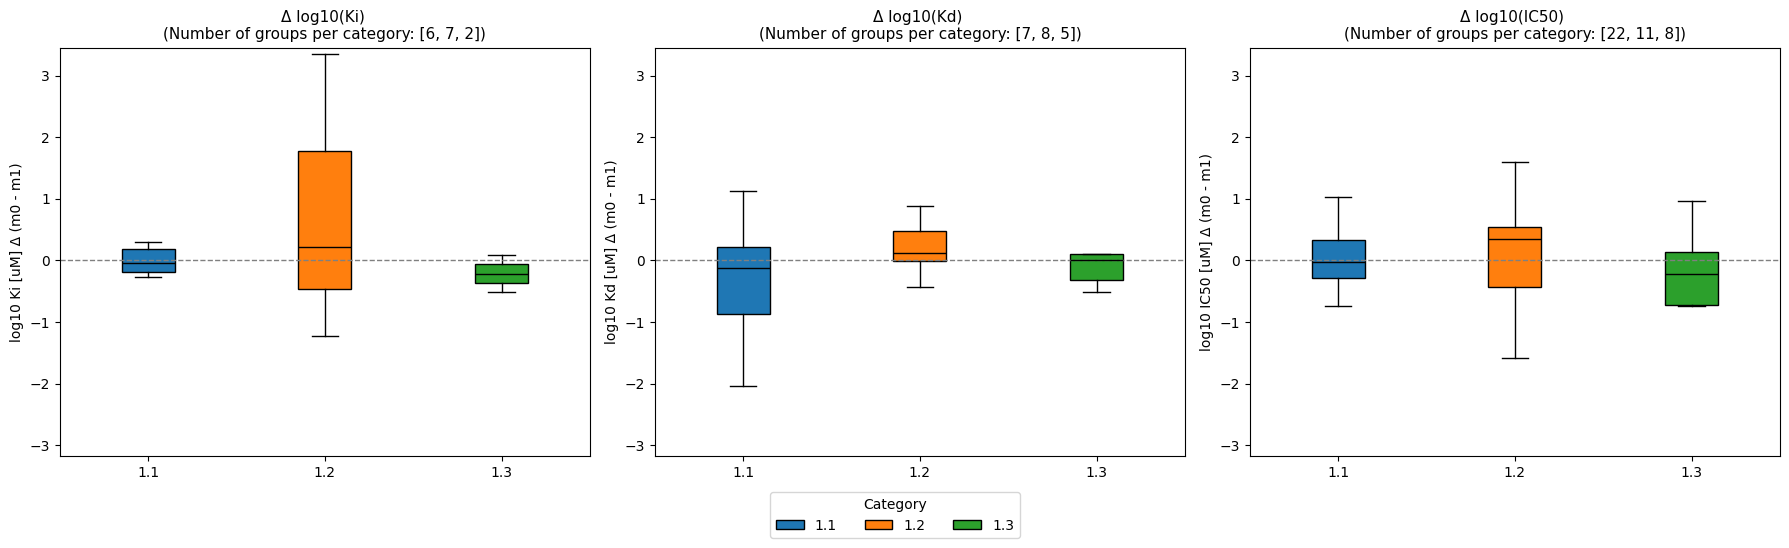

In [208]:
def plot_log_bioactivity_diff_m0_m1_by_category(result_df, layer_a='m0', layer_b='m1'):
    measurements = [
        ('Ki', 'log10 Ki [uM] Δ (m0 - m1)'),
        ('Kd', 'log10 Kd [uM] Δ (m0 - m1)'),
        ('IC50', 'log10 IC50 [uM] Δ (m0 - m1)')
    ]
    categories = sorted(result_df['category'].dropna().unique())
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    color_dict = {cat: colors[i % len(colors)] for i, cat in enumerate(categories)}
    all_diffs = []
    diffs_all_measurements = dict()
    for measurement_key, ylabel in measurements:
        df = result_df[
            result_df['Kd/Ki_pdbbind'].str.contains(measurement_key, case=False, na=False)
            & result_df['measurement_uM'].notnull()
            & (result_df['measurement_uM'] > 0)
        ].copy()
        diffs_per_category = {cat: [] for cat in categories}
        for (group, category), sub_df in df.groupby(['group', 'category']):
            # Ensure at least one value in each layer for the group
            vals_a = sub_df.loc[sub_df['m_layer'] == layer_a, ['measurement_uM', 'kd_ki_ic50_obj']]
            vals_b = sub_df.loc[sub_df['m_layer'] == layer_b, ['measurement_uM', 'kd_ki_ic50_obj']]
            if vals_a['measurement_uM'].notnull().sum() < 1 or vals_b['measurement_uM'].notnull().sum() < 1:
                continue
            obj_a = vals_a['kd_ki_ic50_obj'].unique()
            obj_b = vals_b['kd_ki_ic50_obj'].unique()
            if len(obj_a) != 1 or len(obj_b) != 1 or obj_a[0] != obj_b[0]:
                diff = np.nan
                sub_df.loc[sub_df['m_layer'] == layer_a, 'measurement_uM'] = np.nan
                sub_df.loc[sub_df['m_layer'] == layer_b, 'measurement_uM'] = np.nan
            else:
                mean_log_a = np.log10(vals_a['measurement_uM'].values).mean()
                mean_log_b = np.log10(vals_b['measurement_uM'].values).mean()
                diff = mean_log_a - mean_log_b
            diffs_per_category[category].append(diff)
            all_diffs.append(diff)

        diffs_all_measurements[measurement_key] = {
            k: [v for v in diffs_per_category[k] if not (isinstance(v, float) and np.isnan(v))]
            for k in categories
        }

    all_diffs_nonan = [d for d in all_diffs if not (isinstance(d, float) and np.isnan(d))]
    if all_diffs_nonan:
        min_y = min(-2, np.nanmin(all_diffs_nonan) - 0.1)
        max_y = max(2, np.nanmax(all_diffs_nonan) + 0.1)
    else:
        min_y, max_y = -2, 2

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, (measurement_key, ylabel) in enumerate(measurements):
        diffs_per_category = diffs_all_measurements[measurement_key]
        data = [diffs_per_category[cat] for cat in categories]
        ax = axes[i]
        if not any(len(d) > 0 for d in data):
            ax.set_title(f'No valid data for {measurement_key}')
            ax.set_ylim(min_y, max_y)
            continue

        box = ax.boxplot(
            [d if len(d) > 0 else [np.nan] for d in data],
            patch_artist=True,
            tick_labels=categories,
            showfliers=False
        )
        for patch, cat in zip(box['boxes'], categories):
            patch.set_facecolor(color_dict[cat])
        for median in box['medians']:
            median.set_color('black')
        ax.axhline(0, linestyle='--', color='gray', linewidth=1)
        ax.set_ylabel(ylabel)
        n_counts = [len(diffs_per_category[cat]) for cat in categories]
        ax.set_ylim(min_y, max_y)
        ax.set_title(
            f'Δ log10({measurement_key}) \n(Number of groups per category: {n_counts})',
            fontsize=11
        )
    legend_patches = [Patch(facecolor=color_dict[cat], edgecolor='k', label=cat) for cat in categories]
    fig.legend(handles=legend_patches, title='Category', loc='lower center',
            fontsize='medium', bbox_to_anchor=(0.5, -0.1), ncol=len(categories))
    plt.tight_layout()
    plt.show()

plot_log_bioactivity_diff_m0_m1_by_category(result_df, layer_a='m0', layer_b='m1')

# Bioactivity data with RMSD and SILIRID similarity

In [209]:
print(result_df.groupby('category')['group'].nunique())
display(result_df.head(5))

category
1.1    35
1.2    26
1.3    15
Name: group, dtype: int64


,group,category,pdb_item,pdb_code,ligand_name,matched,pdbbind_info,m_layer,Kd/Ki_pdbbind,reference_pdbbind,liagndname_pdbbind,kd_ki_ic50_obj,measurement_uM,group_hash
721,{'g000066_31f4cbeb1f'},1.2,"A0A1L8F5J9,Q00960_6e7u_HX7_B_503_m0",6e7u,HX7,True,"{'PDB code': '6e7u', 'resolution': '2.27', 're...",m0,Kd=121nM,[Nonstandard assay: pH=7.6] Kd(pH=7.6)=121+/-5...,HX7,Kd,0.121,g000066
723,{'g000066_31f4cbeb1f'},1.2,"A0A1L8F5J9,Q00960_6e7v_T88_B_502_m1",6e7v,T88,True,"{'PDB code': '6e7v', 'resolution': '2.60', 're...",m1,Kd=331nM,[Nonstandard assay: pH=7.6] Kd(pH=7.6)=331+/-2...,T88,Kd,0.331,g000066
796,{'g000360_a142f80b99'},1.2,O00255_4og3_2S6_A_602_m1,4og3,2S6,True,"{'PDB code': '4og3', 'resolution': '2.01', 're...",m1,Kd=285nM,ligand is compound 11 (MIV-3)R isome,2S6,Kd,0.285,g000360
797,{'g000360_a142f80b99'},1.2,O00255_4og4_2VK_A_602_m0,4og4,2VK,True,"{'PDB code': '4og4', 'resolution': '1.45', 're...",m0,Kd=952nM,ligand is compound 11 (MIV-3)S isomer,2VK,Kd,0.952,g000360
1252,{'g000376_db5e8d1217'},1.3,"O15294,P51610_6ma2_J9S_A_1101_m0",6ma2,J9S,True,"{'PDB code': '6ma2', 'resolution': '2.10', 're...",m0,Kd=4.1uM,ligand is compound ent-1a; Kd=4.1+/-3.0uM,J9S,Kd,4.100,g000376


In [210]:
feature_table_updated = pd.read_csv('../Data/Categorization/feature_table.csv')
silirid_fingerprint_slot = pd.read_csv('../Data/Categorization/silirid_fingerprint_slots.csv')
display(feature_table_updated.head(5))
display(silirid_fingerprint_slot.head(5))

,info_file,pipeline_category,manual_label,manual_label_join_method,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,closest_cross_tag_silirid_a,closest_cross_tag_silirid_b,category_reason,n_m0_structures,n_m1_structures,similarity_metric,silirid_vector_length,silirid_count_cap
0,g000001_inchi_b55a025257_inconsistent.csv,1,1.1,from_complex_categories,NaN,NaN,NaN,NaN,NaN,NaN,manual_curation_1.1;inconsistent_atom_count,4,2,structure_silirid_similarity,160,3
1,g000013_inchi_cb46fef414_inconsistent.csv,1,1.3,from_complex_categories,interaction_6b52_OAQ_A_302_m0.tsv,interaction_5tix_OQR_B_302_m1.tsv,3.218487,0.722222,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.3,5,2,structure_silirid_similarity,160,3
2,g000045_inchi_359154acb2_inconsistent.csv,1,1.3,from_complex_categories,interaction_6c92_EQJ_A_401_m0.tsv,interaction_5dj3_5DK_C_500_m1.tsv,2.537710,0.500000,"0,0,0,0,0,0,0,0,0,0,3,0,0,2,0,0,0,0,0,0,0,3,0,...","0,0,0,0,0,0,0,0,0,0,3,0,0,2,0,0,0,0,0,0,0,2,0,...",manual_curation_1.3,12,1,structure_silirid_similarity,160,3
3,g000049_inchi_6924aac1df_inconsistent.csv,1,1.3,from_complex_categories,interaction_5kd6_LBU_B_501_m0.tsv,interaction_5kcy_XBU_B_501_m1.tsv,4.796130,0.227273,"0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,0,0,0,0,0,0,...",manual_curation_1.3,1,3,structure_silirid_similarity,160,3
4,g000066_inchi_31f4cbeb1f_inconsistent.csv,1,1.2,from_complex_categories,interaction_6e7u_HX7_D_402_m0.tsv,interaction_6e7v_T88_D_502_m1.tsv,2.038000,1.000000,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",manual_curation_1.2,2,2,structure_silirid_similarity,160,3


,slot_index,amino_acid,feature_type
0,0,ALA,HYDROPHOBIC
1,1,ALA,AROMATIC
2,2,ALA,NEGATIVE_IONIZABLE
3,3,ALA,POSITIVE_IONIZABLE
4,4,ALA,H_BOND_DONOR


In [211]:
result_df['group_hash'] = result_df['group'].apply(lambda x: x.split('_')[0]).str.strip("{'")
feature_table_updated['groupname_hash'] = feature_table_updated['info_file'].apply(lambda x: x.split('_')[0]).str.strip("{'")
common_groups = set(result_df['group_hash'].unique()).intersection(set(feature_table_updated['groupname_hash'].unique()))
result_common_df = result_df[result_df['group_hash'].isin(common_groups)]
feature_common_df = feature_table_updated[feature_table_updated['groupname_hash'].isin(common_groups)]
merged_df = pd.merge(
    feature_common_df, 
    result_common_df, 
    left_on='groupname_hash', 
    right_on='group_hash', 
    suffixes=('_threshold', '_result')
)

In [212]:
print(len(merged_df))
print(merged_df.groupby('category')['info_file'].nunique())
merged_df.head(5)

180
category
1.1    35
1.2    26
1.3    15
Name: info_file, dtype: int64


,info_file,pipeline_category,manual_label,manual_label_join_method,closest_cross_tag_file_a,closest_cross_tag_file_b,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,closest_cross_tag_silirid_a,closest_cross_tag_silirid_b,...,ligand_name,matched,pdbbind_info,m_layer,Kd/Ki_pdbbind,reference_pdbbind,liagndname_pdbbind,kd_ki_ic50_obj,measurement_uM,group_hash
0,g000066_inchi_31f4cbeb1f_inconsistent.csv,1,1.2,from_complex_categories,interaction_6e7u_HX7_D_402_m0.tsv,interaction_6e7v_T88_D_502_m1.tsv,2.038000,1.00,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",...,HX7,True,"{'PDB code': '6e7u', 'resolution': '2.27', 're...",m0,Kd=121nM,[Nonstandard assay: pH=7.6] Kd(pH=7.6)=121+/-5...,HX7,Kd,0.121,g000066
1,g000066_inchi_31f4cbeb1f_inconsistent.csv,1,1.2,from_complex_categories,interaction_6e7u_HX7_D_402_m0.tsv,interaction_6e7v_T88_D_502_m1.tsv,2.038000,1.00,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",...,T88,True,"{'PDB code': '6e7v', 'resolution': '2.60', 're...",m1,Kd=331nM,[Nonstandard assay: pH=7.6] Kd(pH=7.6)=331+/-2...,T88,Kd,0.331,g000066
2,g000360_inchi_a142f80b99_inconsistent.csv,1,1.2,from_complex_categories,interaction_4og4_2VK_A_602_m0.tsv,interaction_4og3_2S6_A_602_m1.tsv,2.914145,1.00,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",...,2S6,True,"{'PDB code': '4og3', 'resolution': '2.01', 're...",m1,Kd=285nM,ligand is compound 11 (MIV-3)R isome,2S6,Kd,0.285,g000360
3,g000360_inchi_a142f80b99_inconsistent.csv,1,1.2,from_complex_categories,interaction_4og4_2VK_A_602_m0.tsv,interaction_4og3_2S6_A_602_m1.tsv,2.914145,1.00,"0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...","0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...",...,2VK,True,"{'PDB code': '4og4', 'resolution': '1.45', 're...",m0,Kd=952nM,ligand is compound 11 (MIV-3)S isomer,2VK,Kd,0.952,g000360
4,g000376_inchi_db5e8d1217_inconsistent.csv,1,1.3,from_complex_categories,interaction_6ma2_J9S_A_1101_m0.tsv,interaction_6ma5_J9V_A_1101_m1.tsv,3.682154,0.65,"0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,...","0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,...",...,J9S,True,"{'PDB code': '6ma2', 'resolution': '2.10', 're...",m0,Kd=4.1uM,ligand is compound ent-1a; Kd=4.1+/-3.0uM,J9S,Kd,4.100,g000376


In [204]:
def compute_delta_log10_bioactivity_inplace(
    df, 
    value_col='measurement_uM', 
    group_col='groupname_hash', 
    layer_col='m_layer', 
    layer_a='m0', 
    layer_b='m1', 
    obj_col='kd_ki_ic50_obj'
):
    delta_dict = {}
    measurement_nan_groups = set()
    for group, sub_df in df.groupby(group_col):
        sub_a = sub_df[sub_df[layer_col] == layer_a]
        sub_b = sub_df[sub_df[layer_col] == layer_b]
        # Check if exactly one type in obj_col each, and they match
        objs_a = set(sub_a[obj_col].dropna().unique())
        objs_b = set(sub_b[obj_col].dropna().unique())
        if len(objs_a) != 1 or len(objs_b) != 1 or objs_a != objs_b:
            delta_dict[group] = np.nan
            measurement_nan_groups.add(group)
            continue
        common_obj = list(objs_a)[0]
        # get mean for each layer first (for positive values)
        vals_a = sub_a[(sub_a[obj_col] == common_obj) & (sub_a[value_col] > 0)][value_col]
        vals_b = sub_b[(sub_b[obj_col] == common_obj) & (sub_b[value_col] > 0)][value_col]
        if len(vals_a) == 0 or len(vals_b) == 0:
            delta_dict[group] = np.nan
            continue
        mean_a = vals_a.mean()
        mean_b = vals_b.mean()
        if mean_a <= 0 or mean_b <= 0:
            delta_dict[group] = np.nan
            continue
        mean_log_a = np.log10(mean_a)
        mean_log_b = np.log10(mean_b)
        delta_dict[group] = abs(mean_log_a - mean_log_b)
    df['delta_log10_bioactivity'] = df[group_col].map(delta_dict)
    if len(measurement_nan_groups) > 0:
        df.loc[df[group_col].isin(measurement_nan_groups), value_col] = np.nan
    return df

df = compute_delta_log10_bioactivity_inplace(
    merged_df,
    value_col='measurement_uM',
    group_col='groupname_hash',
    layer_col='m_layer',
    layer_a='m0',
    layer_b='m1',
    obj_col='kd_ki_ic50_obj'
)

In [205]:
df.columns

Index(['info_file', 'pipeline_category', 'manual_label',
       'manual_label_join_method', 'closest_cross_tag_file_a',
       'closest_cross_tag_file_b', 'closest_cross_tag_rmsd_A',
       'closest_cross_tag_similarity', 'closest_cross_tag_silirid_a',
       'closest_cross_tag_silirid_b', 'category_reason', 'n_m0_structures',
       'n_m1_structures', 'similarity_metric', 'silirid_vector_length',
       'silirid_count_cap', 'groupname_hash', 'group', 'category', 'pdb_item',
       'pdb_code', 'ligand_name', 'matched', 'pdbbind_info', 'm_layer',
       'Kd/Ki_pdbbind', 'reference_pdbbind', 'liagndname_pdbbind',
       'kd_ki_ic50_obj', 'measurement_uM', 'group_hash',
       'delta_log10_bioactivity'],
      dtype='object')

In [215]:
display(df.sort_values(by='closest_cross_tag_rmsd_A', ascending=False)[['info_file','manual_label','closest_cross_tag_file_a','closest_cross_tag_file_b','m_layer','closest_cross_tag_rmsd_A', 'closest_cross_tag_similarity','delta_log10_bioactivity','Kd/Ki_pdbbind', 'kd_ki_ic50_obj','measurement_uM','reference_pdbbind']].head(20))

,info_file,manual_label,closest_cross_tag_file_a,closest_cross_tag_file_b,m_layer,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,delta_log10_bioactivity,Kd/Ki_pdbbind,kd_ki_ic50_obj,measurement_uM,reference_pdbbind
30,g000479_inchi_cafee50fde_inconsistent.csv,1.2,interaction_5fi6_5XY_C_601_m0.tsv,interaction_5fi2_5XX_A_601_m1.tsv,m1,9.781337,0.285714,0.146128,IC50=0.014uM,IC50,0.014,ligand is compound 12; binding data found in r...
28,g000479_inchi_cafee50fde_inconsistent.csv,1.2,interaction_5fi6_5XY_C_601_m0.tsv,interaction_5fi2_5XX_A_601_m1.tsv,m1,9.781337,0.285714,0.146128,IC50=70nM,IC50,0.070,ligand is compound 7d
29,g000479_inchi_cafee50fde_inconsistent.csv,1.2,interaction_5fi6_5XY_C_601_m0.tsv,interaction_5fi2_5XX_A_601_m1.tsv,m0,9.781337,0.285714,0.146128,IC50=30nM,IC50,0.030,ligand is compound 7e
107,g001101_inchi_d0b8210ed2_inconsistent.csv,1.3,interaction_7okj_VHN_A_201_m0.tsv,interaction_7oki_VHZ_A_201_m1.tsv,m1,6.753362,0.090909,1.028571,IC50=0.25uM,IC50,0.250,ligand is compound 12b(R)
108,g001101_inchi_d0b8210ed2_inconsistent.csv,1.3,interaction_7okj_VHN_A_201_m0.tsv,interaction_7oki_VHZ_A_201_m1.tsv,m0,6.753362,0.090909,1.028571,IC50=2.67uM,IC50,2.670,ligand is compound 12c(S)
156,g001705_inchi_e9ddf9e7bd_inconsistent.csv,1.3,interaction_5n55_8NN_A_502_m0.tsv,interaction_5nai_93W_A_304_m1.tsv,m0,6.589008,0.382353,0.109747,Kd=1.03uM,Kd,1.030,VIM-5(Oxidized):compound 2
158,g001705_inchi_e9ddf9e7bd_inconsistent.csv,1.3,interaction_5n55_8NN_A_502_m0.tsv,interaction_5nai_93W_A_304_m1.tsv,m1,6.589008,0.382353,0.109747,Kd=0.8uM,Kd,0.800,VIM-5(Oxidized):compound 1
157,g001705_inchi_e9ddf9e7bd_inconsistent.csv,1.3,interaction_5n55_8NN_A_502_m0.tsv,interaction_5nai_93W_A_304_m1.tsv,m1,6.589008,0.382353,0.109747,Kd=0.8uM,Kd,0.800,VIM-5:compound 1
154,g001687_inchi_f52c7f4b8a_inconsistent.csv,1.2,interaction_7oeg_UEE_A_601_m0.tsv,interaction_7ni8_UEE_A_601_m1.tsv,m1,6.464179,0.666667,0.389667,IC50=0.53uM,IC50,0.530,ligand is compound 29(R); binding data by HTRF...
155,g001687_inchi_f52c7f4b8a_inconsistent.csv,1.2,interaction_7oeg_UEE_A_601_m0.tsv,interaction_7ni8_UEE_A_601_m1.tsv,m0,6.464179,0.666667,0.389667,IC50=1.3uM,IC50,1.300,ligand is compound 29(S); HTRF assay


In [223]:
display(df.sort_values(by='closest_cross_tag_rmsd_A', ascending=False)[['info_file','manual_label','closest_cross_tag_file_a','closest_cross_tag_file_b','m_layer','closest_cross_tag_rmsd_A', 'closest_cross_tag_similarity','delta_log10_bioactivity','Kd/Ki_pdbbind', 'kd_ki_ic50_obj','measurement_uM','reference_pdbbind']].head(20))


,info_file,manual_label,closest_cross_tag_file_a,closest_cross_tag_file_b,m_layer,closest_cross_tag_rmsd_A,closest_cross_tag_similarity,delta_log10_bioactivity,Kd/Ki_pdbbind,kd_ki_ic50_obj,measurement_uM,reference_pdbbind
30,g000479_inchi_cafee50fde_inconsistent.csv,1.2,interaction_5fi6_5XY_C_601_m0.tsv,interaction_5fi2_5XX_A_601_m1.tsv,m1,9.781337,0.285714,0.146128,IC50=0.014uM,IC50,0.014,ligand is compound 12; binding data found in r...
28,g000479_inchi_cafee50fde_inconsistent.csv,1.2,interaction_5fi6_5XY_C_601_m0.tsv,interaction_5fi2_5XX_A_601_m1.tsv,m1,9.781337,0.285714,0.146128,IC50=70nM,IC50,0.070,ligand is compound 7d
29,g000479_inchi_cafee50fde_inconsistent.csv,1.2,interaction_5fi6_5XY_C_601_m0.tsv,interaction_5fi2_5XX_A_601_m1.tsv,m0,9.781337,0.285714,0.146128,IC50=30nM,IC50,0.030,ligand is compound 7e
107,g001101_inchi_d0b8210ed2_inconsistent.csv,1.3,interaction_7okj_VHN_A_201_m0.tsv,interaction_7oki_VHZ_A_201_m1.tsv,m1,6.753362,0.090909,1.028571,IC50=0.25uM,IC50,0.250,ligand is compound 12b(R)
108,g001101_inchi_d0b8210ed2_inconsistent.csv,1.3,interaction_7okj_VHN_A_201_m0.tsv,interaction_7oki_VHZ_A_201_m1.tsv,m0,6.753362,0.090909,1.028571,IC50=2.67uM,IC50,2.670,ligand is compound 12c(S)
156,g001705_inchi_e9ddf9e7bd_inconsistent.csv,1.3,interaction_5n55_8NN_A_502_m0.tsv,interaction_5nai_93W_A_304_m1.tsv,m0,6.589008,0.382353,0.109747,Kd=1.03uM,Kd,1.030,VIM-5(Oxidized):compound 2
158,g001705_inchi_e9ddf9e7bd_inconsistent.csv,1.3,interaction_5n55_8NN_A_502_m0.tsv,interaction_5nai_93W_A_304_m1.tsv,m1,6.589008,0.382353,0.109747,Kd=0.8uM,Kd,0.800,VIM-5(Oxidized):compound 1
157,g001705_inchi_e9ddf9e7bd_inconsistent.csv,1.3,interaction_5n55_8NN_A_502_m0.tsv,interaction_5nai_93W_A_304_m1.tsv,m1,6.589008,0.382353,0.109747,Kd=0.8uM,Kd,0.800,VIM-5:compound 1
154,g001687_inchi_f52c7f4b8a_inconsistent.csv,1.2,interaction_7oeg_UEE_A_601_m0.tsv,interaction_7ni8_UEE_A_601_m1.tsv,m1,6.464179,0.666667,0.389667,IC50=0.53uM,IC50,0.530,ligand is compound 29(R); binding data by HTRF...
155,g001687_inchi_f52c7f4b8a_inconsistent.csv,1.2,interaction_7oeg_UEE_A_601_m0.tsv,interaction_7ni8_UEE_A_601_m1.tsv,m0,6.464179,0.666667,0.389667,IC50=1.3uM,IC50,1.300,ligand is compound 29(S); HTRF assay


# Approved drugs that have the individual bioactivity measurement

In [17]:
matching_groups = set(filtered_df['group']) & set(all_similarity_most_similar_df[mask]['group'])
matching_groups_df = filtered_df[filtered_df['group'].isin(matching_groups)].copy()
print(f"Number of groups in that have identical approved drugs in DrugBank: {matching_groups_df['group'].nunique()}")
category_counts_per_group = matching_groups_df.groupby('category')['group'].nunique()
print("Number of groups in each category:")
print(category_counts_per_group)

Number of groups in that have identical approved drugs in DrugBank: 6
Number of groups in each category:
category
1.1    3
1.2    1
1.3    2
Name: group, dtype: int64


In [18]:
display(matching_groups_df.head(3))

,group,category,pdb_item,pdb_code,ligand_name,matched,pdbbind_info,m_layer,Kd/Ki_pdbbind,reference_pdbbind,liagndname_pdbbind
103,{'g000574_f89a5f81db'},1.1,P02766_1eta_T44_1_128_m0,1eta,T44,True,"{'PDB code': '1eta', 'resolution': '1.70', 're...",m0,IC50=2.19uM,ligand is T4; amyloid fibril formation assay,T44
104,{'g000574_f89a5f81db'},1.1,P02766_1etb_T44_1_128_m0,1etb,T44,True,"{'PDB code': '1etb', 'resolution': '1.70', 're...",m0,IC50=2.2uM,"[Nonstandard assay: Temp=37C, pH=4.4] ligand i...",T44
105,{'g000574_f89a5f81db'},1.1,P02766_1ict_T44_C_128_m0,1ict,T44,True,"{'PDB code': '1ict', 'resolution': '3.00', 're...",m0,IC50=2.19uM,None,T44
